In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score, davies_bouldin_score
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import datetime as dt
from sklearn.neighbors import NearestNeighbors
from itertools import combinations
from collections import defaultdict
import community.community_louvain as community_louvain
from sklearn.cluster import SpectralClustering

### Download Data

In [27]:
# import kagglehub

# Download latest version
# path = kagglehub.dataset_download("hellbuoy/online-retail-customer-clustering")

# print("Path to dataset files:", path)

Move this CSV file to the same directory as the Jupyter Notebook.

### Step 1: Load Data

In [28]:
all_data = pd.read_csv('OnlineRetail.csv', encoding='latin1')
display(all_data.head())
display(all_data.tail())
print(all_data.shape)
print(all_data.info())
print(all_data.describe())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09-12-2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09-12-2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09-12-2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09-12-2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,09-12-2011 12:50,4.95,12680.0,France


(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000   

### Step 2: Data Cleaning and Preprocessing

In [29]:
# Make a copy of the dataframe to avoid modifying the original data
df_cleaned = all_data.copy()

# --- 1. Remove transactions without a CustomerID ---
# As we are doing customer segmentation, we need to identify each customer.
df_cleaned.dropna(subset=['CustomerID'], inplace=True)
print(f"Shape after removing null CustomerIDs: {df_cleaned.shape}")

# --- 2. Convert CustomerID to integer ---
# Now that nulls are removed, we can convert this to a more appropriate data type.
df_cleaned['CustomerID'] = df_cleaned['CustomerID'].astype(int)

# --- 3. Remove returned items (negative Quantity) ---
# We are interested in purchasing behavior, so returns should be excluded.
df_cleaned = df_cleaned[df_cleaned['Quantity'] > 0]
print(f"Shape after removing negative quantities: {df_cleaned.shape}")

# --- 4. Remove transactions with a unit price of zero ---
# These are likely not actual purchases and can skew monetary calculations.
df_cleaned = df_cleaned[df_cleaned['UnitPrice'] > 0]
print(f"Shape after removing zero unit prices: {df_cleaned.shape}")

# --- 5. Convert InvoiceDate to datetime format ---
# This is crucial for calculating Recency.
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'], format='%d-%m-%Y %H:%M')

# --- 6. Create the TotalPrice column ---
# This is needed for calculating the Monetary value in RFM analysis.
df_cleaned['TotalPrice'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']

# --- Display the cleaned data's info ---
print("\nCleaned Data Information:")
df_cleaned.info()

# --- Display the cleaned data's description ---
print("\nCleaned Data Description:")
display(df_cleaned.describe())

# --- Display the first few rows of the cleaned data ---
print("\nCleaned Data Head:")
display(df_cleaned.head())

Shape after removing null CustomerIDs: (406829, 8)
Shape after removing negative quantities: (397924, 8)
Shape after removing zero unit prices: (397884, 8)

Cleaned Data Information:
<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  int32         
 7   Country      397884 non-null  object        
 8   TotalPrice   397884 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(4)
memory usage: 28.8+ MB

Cleaned Data Description:


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,179.331775,NaN,22.097877,1713.141560,309.071041



Cleaned Data Head:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


### Step 3: RFM (Recency, Frequency, Monetary) Feature Engineering

In [30]:
# --- Calculate RFM Metrics ---

# To calculate recency, we need a reference date. We'll use the day after the last transaction in the dataset.
snapshot_date = df_cleaned['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Snapshot date for Recency calculation: {snapshot_date}")

# Group by CustomerID and calculate RFM values
rfm_df = df_cleaned.groupby('CustomerID').agg({
    'InvoiceDate': lambda date: (snapshot_date - date.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                      # Frequency (count of unique invoices)
    'TotalPrice': 'sum'                                          # Monetary
})

# Rename the columns for clarity
rfm_df.rename(columns={'InvoiceDate': 'Recency',
                       'InvoiceNo': 'Frequency',
                       'TotalPrice': 'Monetary'}, inplace=True)

# Display the first few rows of the new RFM dataframe
print("\nRFM DataFrame Head:")
display(rfm_df.head())

# Display descriptive statistics for the RFM values
print("\nRFM DataFrame Description:")
display(rfm_df.describe())
display(rfm_df.shape)

Snapshot date for Recency calculation: 2011-12-10 12:50:00

RFM DataFrame Head:


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40



RFM DataFrame Description:


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


(4338, 3)

### Step 4: Data Transformation and Scaling

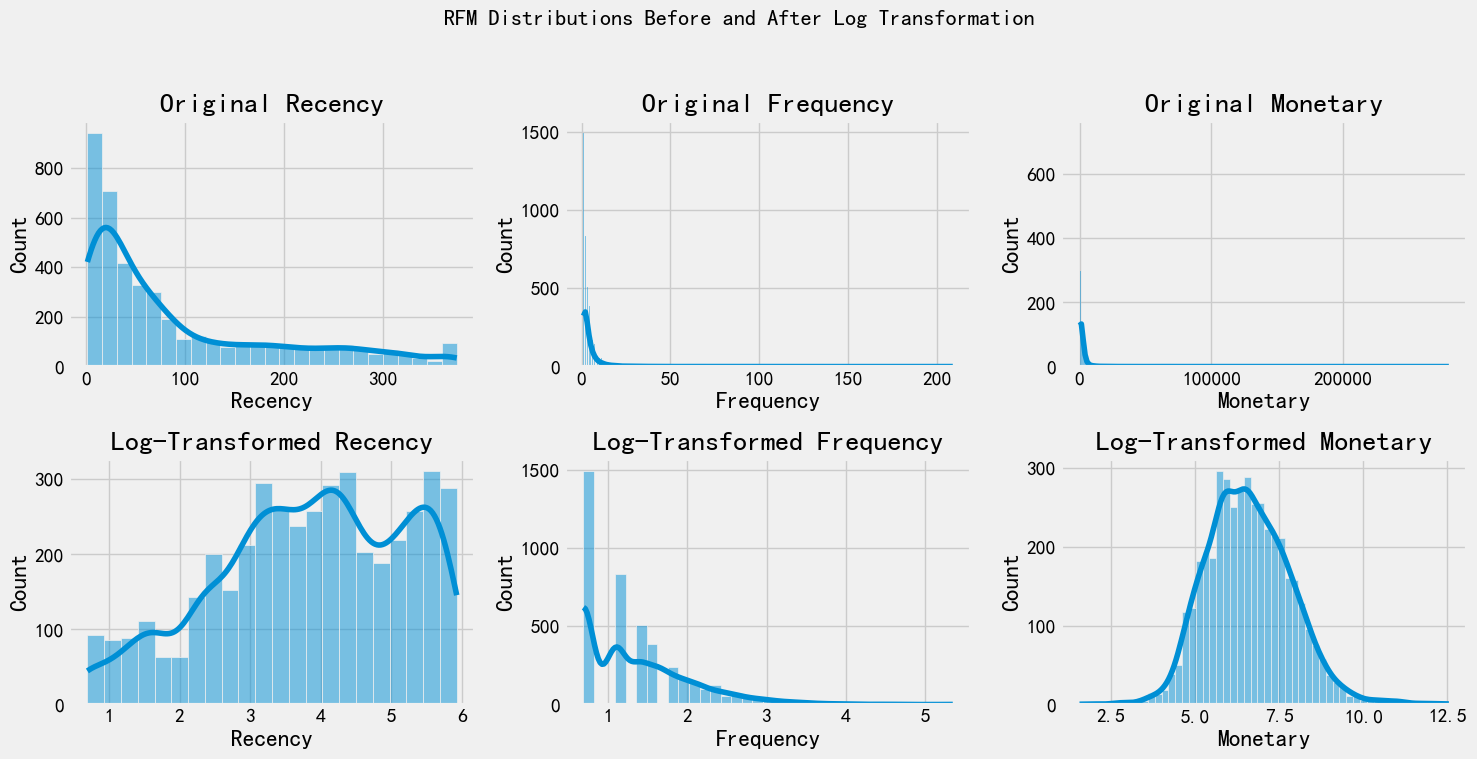


Scaled RFM DataFrame Head:


,Recency,Frequency,Monetary
CustomerID,,,
12346,1.461993,-0.955214,3.706225
12347,-2.038734,1.074425,1.411843
12348,0.373104,0.386304,0.716489
12349,-0.623086,-0.955214,0.698739
12350,1.424558,-0.955214,-0.618962



Scaled RFM DataFrame Description:


,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,-8.025955e-17,-8.189750e-18,2.817274e-16
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-2.341296e+00,-9.552143e-01,-4.004574e+00
25%,-6.613615e-01,-9.552143e-01,-6.856676e-01
50%,8.992557e-02,-3.615828e-01,-6.218718e-02
75%,8.447915e-01,6.532370e-01,6.541861e-01
max,1.564198e+00,5.858535e+00,4.731591e+00


In [31]:
# --- 1. Handle Skewness with Log Transformation ---
# We apply a log transformation to reduce the skewness of the RFM data.
# Adding 1 to each value to avoid log(0) issues.
rfm_log_df = rfm_df.apply(lambda x: np.log(x + 1))

# Let's visualize the distributions before and after the log transformation
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('RFM Distributions Before and After Log Transformation', fontsize=16)

# Before transformation
sns.histplot(rfm_df['Recency'], ax=axes[0, 0], kde=True).set_title('Original Recency')
sns.histplot(rfm_df['Frequency'], ax=axes[0, 1], kde=True).set_title('Original Frequency')
sns.histplot(rfm_df['Monetary'], ax=axes[0, 2], kde=True).set_title('Original Monetary')

# After transformation
sns.histplot(rfm_log_df['Recency'], ax=axes[1, 0], kde=True).set_title('Log-Transformed Recency')
sns.histplot(rfm_log_df['Frequency'], ax=axes[1, 1], kde=True).set_title('Log-Transformed Frequency')
sns.histplot(rfm_log_df['Monetary'], ax=axes[1, 2], kde=True).set_title('Log-Transformed Monetary')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# --- 2. Scale the Data with StandardScaler ---
# StandardScaler standardizes features by removing the mean and scaling to unit variance.
scaler = StandardScaler()

# Fit and transform the log-transformed data
rfm_scaled = scaler.fit_transform(rfm_log_df)

# The result is a NumPy array. Let's convert it back to a DataFrame for easier inspection.
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm_log_df.index, columns=rfm_log_df.columns)

# Display the first few rows of the scaled data
print("\nScaled RFM DataFrame Head:")
display(rfm_scaled_df.head())

# Display the description of the scaled data
print("\nScaled RFM DataFrame Description:")
display(rfm_scaled_df.describe())

### Step 5: General Clustering Algorithms (K-means & DBSCAN)

K-Means

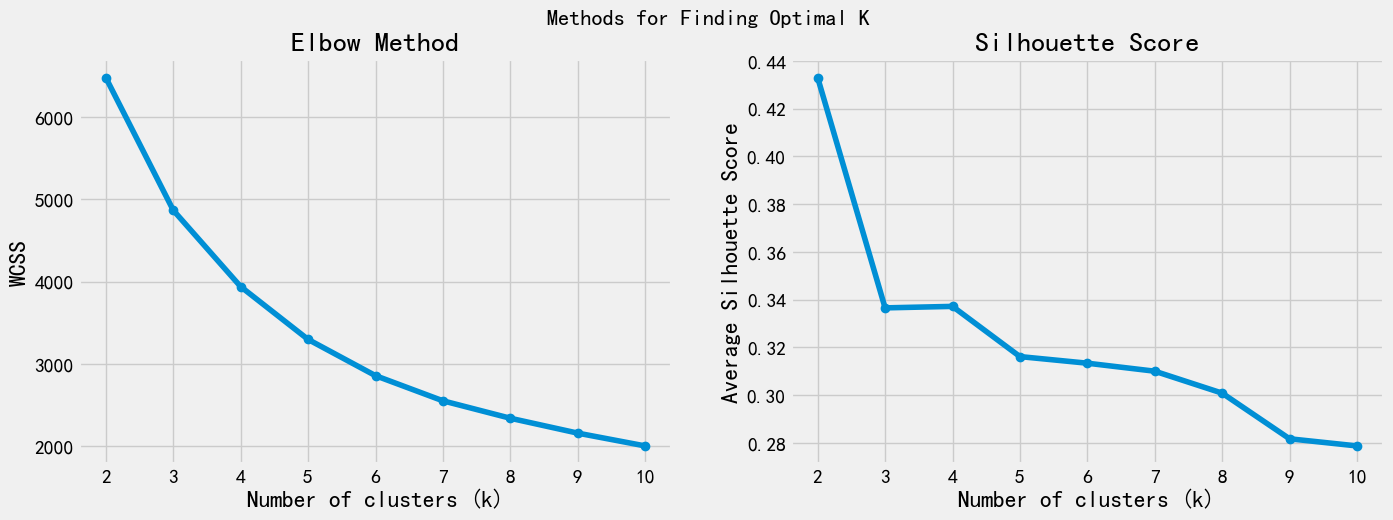

In [32]:
# --- 1. Finding Optimal K using Elbow Method and Silhouette Score ---
wcss = []
silhouette_scores = []
k_range = range(2, 11)  # Test k from 2 to 10

for k in k_range:
    # K-means
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    
    # WCSS (inertia)
    wcss.append(kmeans.inertia_)
    
    # Silhouette Score
    score = silhouette_score(rfm_scaled_df, kmeans.labels_)
    silhouette_scores.append(score)

# Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Methods for Finding Optimal K', fontsize=16)

# Elbow Method Plot
ax1.plot(k_range, wcss, marker='o')
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('WCSS')

# Silhouette Score Plot
ax2.plot(k_range, silhouette_scores, marker='o')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Average Silhouette Score')

plt.show()

According to above result, the best k = 4

--- K-means Model Evaluation (k=4) ---
Average Silhouette Score: 0.3371
Davies-Bouldin Index: 1.0101
-----------------------------------------

--- K-means Cluster Analysis (RFM Averages) ---


,Recency,Frequency,Monetary,Count
KMeans_Cluster,,,,
0,18.12,2.15,551.82,837
1,12.13,13.71,8074.27,716
2,71.08,4.08,1802.83,1173
3,182.50,1.32,343.45,1612


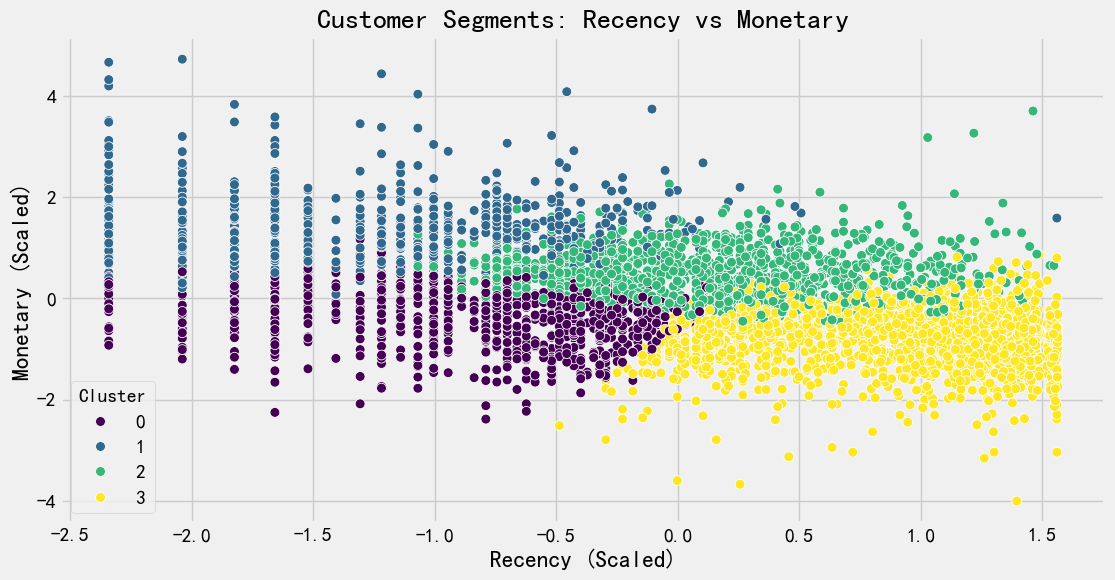

In [33]:
# --- 2. Applying K-means with k=4 ---
k = 4
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
kmeans.fit(rfm_scaled_df)

# Add the cluster labels to both the original and scaled RFM dataframes
rfm_df['KMeans_Cluster'] = kmeans.labels_
rfm_scaled_df['KMeans_Cluster'] = kmeans.labels_

# --- 3. Evaluating the K-means Model ---
# We will use the metrics specified in the project requirements
silhouette_avg = silhouette_score(rfm_scaled_df.drop('KMeans_Cluster', axis=1), kmeans.labels_)
db_score = davies_bouldin_score(rfm_scaled_df.drop('KMeans_Cluster', axis=1), kmeans.labels_)

print(f"--- K-means Model Evaluation (k={k}) ---")
print(f"Average Silhouette Score: {silhouette_avg:.4f}")
print(f"Davies-Bouldin Index: {db_score:.4f}")
print("-----------------------------------------\n")


# --- 4. Analyzing and Interpreting the Customer Segments ---
# We group by the cluster label and calculate the mean for each RFM attribute in the original (unscaled) data
# This makes the results human-readable
cluster_analysis = rfm_df.groupby('KMeans_Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

# Also get the size of each cluster
cluster_analysis['Count'] = rfm_df['KMeans_Cluster'].value_counts()

print("--- K-means Cluster Analysis (RFM Averages) ---")
display(cluster_analysis)

# --- 5. Visualizing the Clusters ---
# It's helpful to visualize the segments to better understand them
plt.figure(figsize=(12, 6))
sns.scatterplot(data=rfm_scaled_df, x='Recency', y='Monetary', hue='KMeans_Cluster', palette='viridis', s=50)
plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Scaled)')
plt.ylabel('Monetary (Scaled)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

DBSCAN

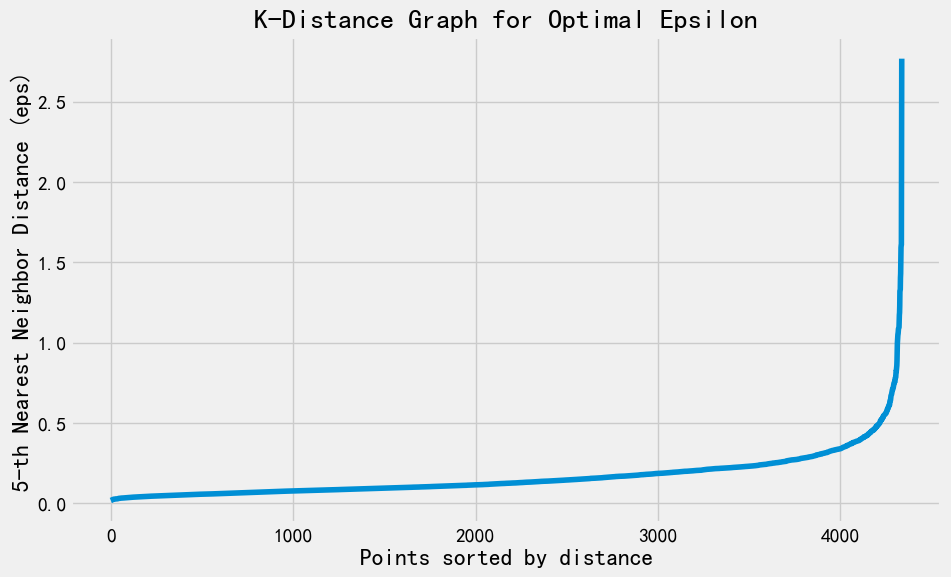

In [34]:
# --- 1. Finding optimal eps for DBSCAN ---
# We use the k-distance graph. min_samples is set based on the heuristic 2 * num_features.
min_samples = 6 
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(rfm_scaled_df.drop('KMeans_Cluster', axis=1)) # Use data without previous labels
distances, indices = neighbors_fit.kneighbors(rfm_scaled_df.drop('KMeans_Cluster', axis=1))

# Sort the distances to the (min_samples-1)-th neighbor and plot
sorted_distances = np.sort(distances[:, min_samples-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(sorted_distances)
plt.title('K-Distance Graph for Optimal Epsilon')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{min_samples-1}-th Nearest Neighbor Distance (eps)')
plt.grid(True)
plt.show()

--- DBSCAN Model Results ---
Estimated number of clusters: 3
Estimated number of noise points (outliers): 64
--------------------------------

--- DBSCAN Model Evaluation (on clustered points only) ---
Average Silhouette Score: 0.2168
Davies-Bouldin Index: 0.8572
----------------------------------------------------------

--- DBSCAN Cluster Analysis (excluding outliers) ---


,Recency_Mean,Frequency_Mean,Monetary_Mean,Count
DBSCAN_Cluster,,,,
0,59.20,5.36,2001.92,2788
1,156.92,1.00,355.88,1484
2,9.50,20.50,30134.94,2


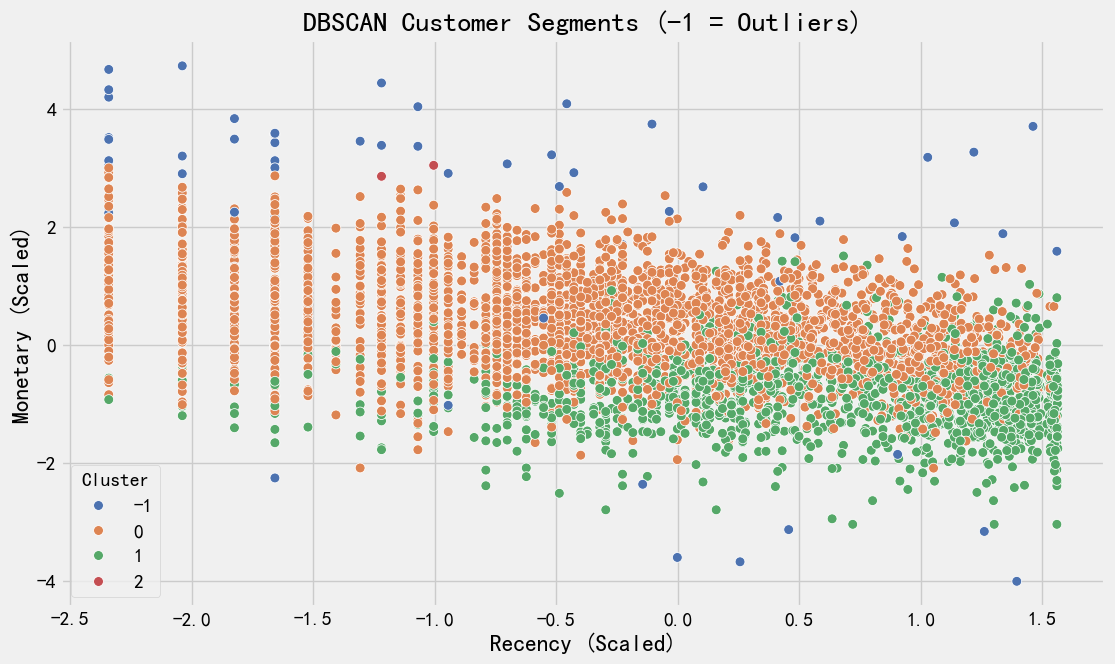

In [35]:
# --- 2. Applying DBSCAN with Chosen Parameters ---
# Parameters determined from our analysis
eps = 0.5
min_samples = 6

# Initialize and run the DBSCAN algorithm
dbscan = DBSCAN(eps=eps, min_samples=min_samples)

# We use .fit_predict() on the scaled data (without any previous cluster labels)
# The KMeans_Cluster column is dropped to ensure we are only using RFM features
dbscan_labels = dbscan.fit_predict(rfm_scaled_df.drop(['KMeans_Cluster'], axis=1))

# Add the new DBSCAN cluster labels to our dataframes
# Note: The label -1 is assigned by DBSCAN to noise points (outliers).
rfm_df['DBSCAN_Cluster'] = dbscan_labels
rfm_scaled_df['DBSCAN_Cluster'] = dbscan_labels

# --- 3. Evaluating and Analyzing DBSCAN Results ---
# Count the number of unique clusters and the number of noise points
num_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
num_noise = list(dbscan_labels).count(-1)

print(f"--- DBSCAN Model Results ---")
print(f"Estimated number of clusters: {num_clusters}")
print(f"Estimated number of noise points (outliers): {num_noise}")
print("--------------------------------\n")


# For evaluation metrics, we should only consider the points that form a cluster (i.e., not noise)
core_samples_mask = dbscan_labels != -1
labels = dbscan_labels[core_samples_mask]
core_data = rfm_scaled_df.loc[core_samples_mask, ['Recency', 'Frequency', 'Monetary']]

# Only calculate scores if more than one cluster is found
if num_clusters > 1:
    silhouette_avg_db = silhouette_score(core_data, labels)
    db_score_db = davies_bouldin_score(core_data, labels)
    print(f"--- DBSCAN Model Evaluation (on clustered points only) ---")
    print(f"Average Silhouette Score: {silhouette_avg_db:.4f}")
    print(f"Davies-Bouldin Index: {db_score_db:.4f}")
    print("----------------------------------------------------------\n")
else:
    print("Cannot calculate evaluation scores because only one or zero clusters were found.")


# Analyze the characteristics of the clusters found by DBSCAN (excluding noise)
print("--- DBSCAN Cluster Analysis (excluding outliers) ---")
dbscan_analysis = rfm_df[rfm_df['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster').agg(
    Recency_Mean=('Recency', 'mean'),
    Frequency_Mean=('Frequency', 'mean'),
    Monetary_Mean=('Monetary', 'mean'),
    Count=('DBSCAN_Cluster', 'count')
).round(2)

display(dbscan_analysis)


# --- 4. Visualizing the DBSCAN Clusters ---
plt.figure(figsize=(12, 7))
sns.scatterplot(data=rfm_scaled_df, x='Recency', y='Monetary', hue='DBSCAN_Cluster', palette='deep', s=50)
plt.title('DBSCAN Customer Segments (-1 = Outliers)')
plt.xlabel('Recency (Scaled)')
plt.ylabel('Monetary (Scaled)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

### Step 6: Graph-Based Clustering

In [36]:
# --- 1. Create an inverted index (Item -> Customers) ---
# We use the cleaned transactional data for this
item_customers = df_cleaned.groupby('StockCode')['CustomerID'].apply(set).to_dict()

# --- 2. Calculate edge weights (number of common products) ---
# This dictionary will store pairs of customers and their common item count
edge_weights = defaultdict(int)

# Iterate through the customers for each item
print("Calculating edge weights based on common products...")
for item, customers in item_customers.items():
    # Only consider items bought by more than one and fewer than 100 customers 
    # to avoid noise from very rare or extremely common items.
    if 1 < len(customers) < 100:
        # Generate all pairs of customers who bought this item
        for customer1, customer2 in combinations(customers, 2):
            # The key is a sorted tuple to ensure (A,B) is the same as (B,A)
            edge_weights[tuple(sorted((customer1, customer2)))] += 1

print("Edge weight calculation complete.")

# --- 3. Create the graph ---
# We will only create an edge if the customers have a significant number of common products.
# Let's set the threshold after inspecting the weights.
weights = pd.Series(edge_weights)
print("\nDescription of common product counts (edge weights):")
display(weights.describe())

# A threshold of 5 seems reasonable based on the distribution
# It will capture meaningful relationships without making the graph too dense.
THRESHOLD = 5 

# Create a graph object
G = nx.Graph()

# Add nodes (all customers)
G.add_nodes_from(rfm_df.index)

# Add edges based on the threshold
for (customer1, customer2), weight in edge_weights.items():
    if weight >= THRESHOLD:
        G.add_edge(customer1, customer2, weight=weight)
        
# --- 4. Print Graph Statistics ---
# Remove isolated nodes (customers with no connections) for cleaner analysis
isolated_nodes = [node for node, degree in dict(G.degree()).items() if degree == 0]
G.remove_nodes_from(isolated_nodes)

print("\n--- Customer Similarity Graph Statistics ---")
print(f"Number of nodes (customers): {G.number_of_nodes()}")
print(f"Number of edges (connections): {G.number_of_edges()}")
print("------------------------------------------")

Calculating edge weights based on common products...
Edge weight calculation complete.

Description of common product counts (edge weights):


count    1.207259e+06
mean     1.929045e+00
std      2.699930e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      4.590000e+02
dtype: float64


--- Customer Similarity Graph Statistics ---
Number of nodes (customers): 2712
Number of edges (connections): 76080
------------------------------------------


In [37]:
# --- 1. Apply the Louvain Algorithm ---
partition = community_louvain.best_partition(G)

num_communities = len(set(partition.values()))
print(f"Louvain algorithm found {num_communities} communities.")

modularity = community_louvain.modularity(partition, G)
print(f"Modularity of the partition is: {modularity:.4f}")

# --- 2. Add community labels to RFM dataframe ---
louvain_labels = pd.Series(partition, name='Louvain_Community')
rfm_df['Louvain_Community'] = louvain_labels
rfm_df['Louvain_Community'] = rfm_df['Louvain_Community'].fillna(-1).astype(int)

Louvain algorithm found 6 communities.
Modularity of the partition is: 0.1563



Preparing graph for visualization... (this may take a moment)


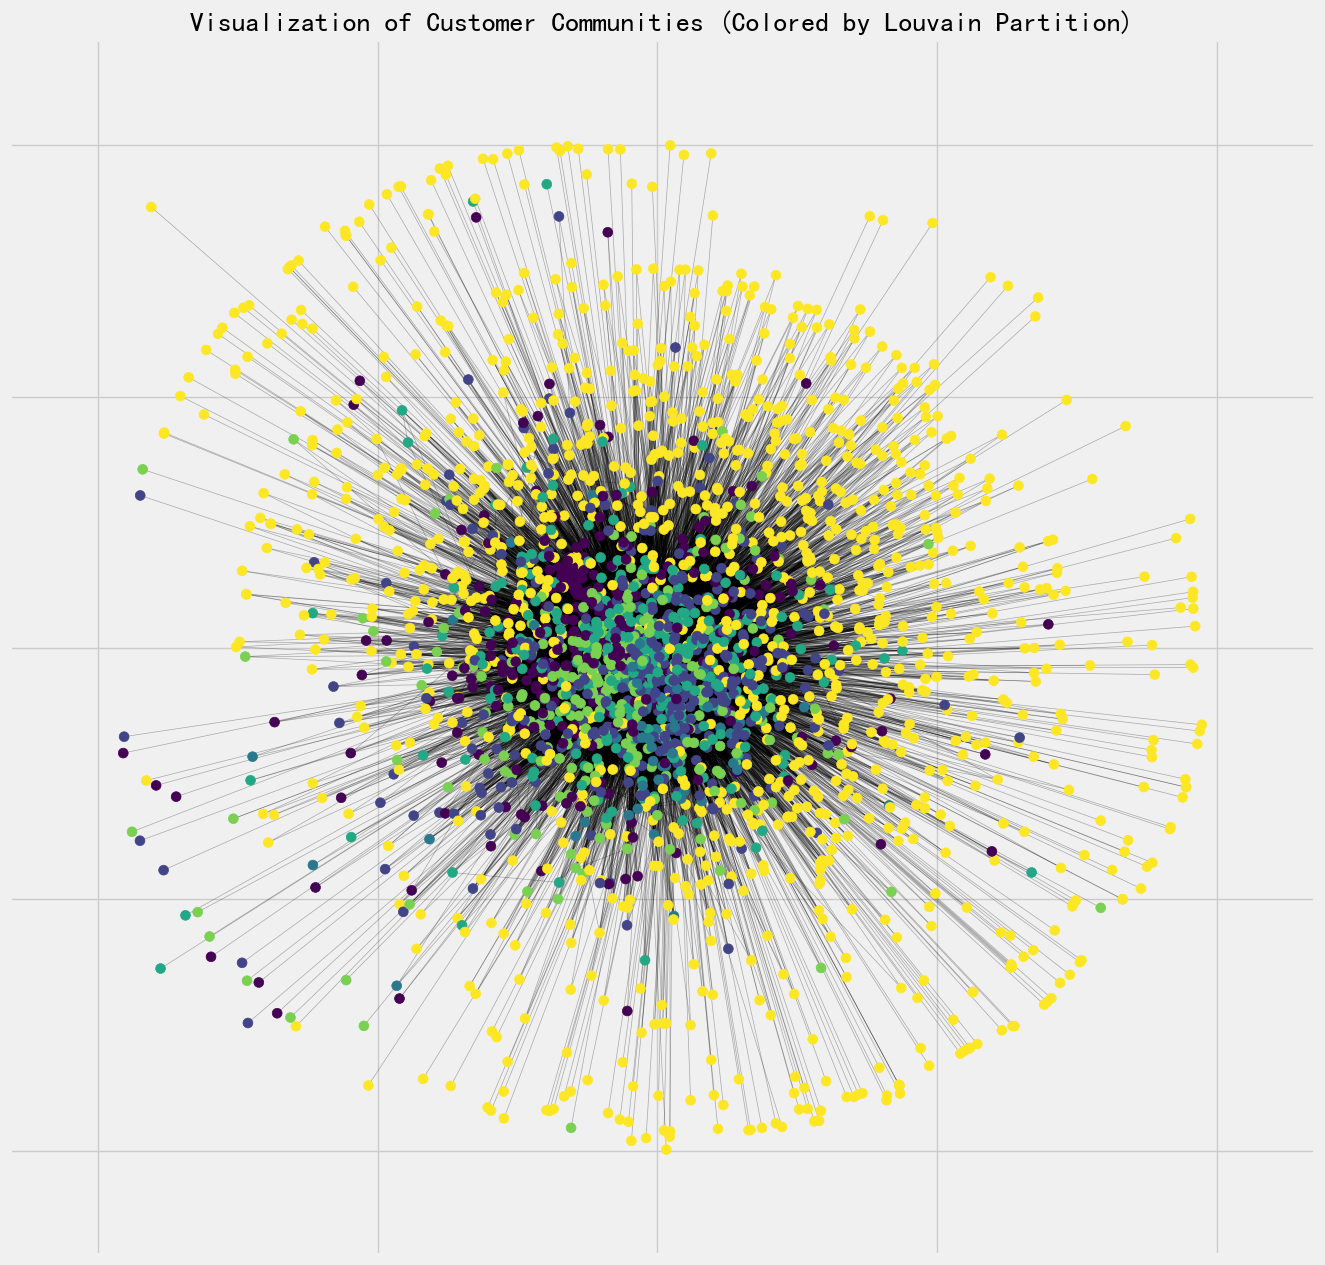

In [38]:
print("\nPreparing graph for visualization... (this may take a moment)")
plt.figure(figsize=(15, 15))

# Use a spring layout to position the nodes. It's a force-directed layout,
# so nodes with more connections will be pulled closer together.
pos = nx.spring_layout(G, iterations=50, seed=42)

# Get the community labels from the 'partition' dictionary to color the nodes.
# We use .get(node, 0) to handle any potential node mismatches safely.
node_colors = [partition.get(node, 0) for node in G.nodes()]

# Draw the graph components
# Nodes are colored by their community ID.
# Edges are faint to keep the focus on the community structure.
nx.draw_networkx_nodes(G, pos, node_size=50, cmap=plt.cm.viridis, node_color=node_colors)
nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.5)

plt.title("Visualization of Customer Communities (Colored by Louvain Partition)", fontsize=20)
plt.show()

Our customer base is not a single, uniform group. As the graph visualization shows, it has a large, densely connected mainstream core where the majority of customers buy popular, shared products. Surrounding this core are several smaller, niche communities of customers who are less connected but share specific interests among themselves. The graph clustering algorithms were successfully able to identify and separate these distinct market segments.

In [39]:
# --- 1. Prepare Data for Spectral Clustering ---
# We create an ordered list of nodes from our graph 'G'
graph_nodes = list(G.nodes())

# Convert the NetworkX graph to a SciPy sparse matrix
adjacency_matrix = nx.to_scipy_sparse_array(G, nodelist=graph_nodes)

# --- FIX FOR ValueError: Convert sparse matrix indices to 32-bit integers ---
# Scikit-learn's spectral clustering requires int32 indices, but networkx may create int64.
print(f"Original adjacency matrix index dtype: {adjacency_matrix.indices.dtype}")
adjacency_matrix.indices = adjacency_matrix.indices.astype(np.int32)
adjacency_matrix.indptr = adjacency_matrix.indptr.astype(np.int32)
print(f"Corrected adjacency matrix index dtype: {adjacency_matrix.indices.dtype}")
# ----------------------------------------------------------------------------

# --- 2. Apply Spectral Clustering ---
# We set n_clusters to 6, the number found by Louvain
n_clusters_spectral = 6

print(f"\nApplying Spectral Clustering to find {n_clusters_spectral} clusters...")

# Initialize the SpectralClustering model
sc = SpectralClustering(
    n_clusters=n_clusters_spectral,
    affinity='precomputed',    # We provide the adjacency matrix directly
    assign_labels='kmeans',    # Method to extract discrete clusters
    random_state=42            # For reproducibility
)

# Fit the model to our CORRECTED adjacency matrix
spectral_labels_array = sc.fit_predict(adjacency_matrix)

print("Spectral Clustering complete.")

# --- 3. Add Spectral Cluster Labels to the RFM DataFrame ---
# Map the cluster labels back to the correct CustomerIDs
spectral_labels = pd.Series(spectral_labels_array, index=graph_nodes, name='Spectral_Cluster')

# Join the labels with our main rfm_df
rfm_df = rfm_df.join(spectral_labels)

# Fill NaN for isolated nodes with -1 and convert to integer type
rfm_df['Spectral_Cluster'] = rfm_df['Spectral_Cluster'].fillna(-1).astype(int)

# --- 4. Display Results ---
print("\n--- Spectral Clustering Analysis (Community Sizes) ---")
display(rfm_df['Spectral_Cluster'].value_counts())

Original adjacency matrix index dtype: int32
Corrected adjacency matrix index dtype: int32

Applying Spectral Clustering to find 6 clusters...
Spectral Clustering complete.

--- Spectral Clustering Analysis (Community Sizes) ---


Spectral_Cluster
 0    1914
-1    1626
 3     709
 5      36
 4      30
 2      20
 1       3
Name: count, dtype: int64

In [40]:
# --- 5. Analyze the Characteristics of the Spectral Communities ---

# We will group by the cluster label and calculate the mean RFM values
# We exclude the isolated customers (-1) from this part of the analysis
spectral_analysis = rfm_df[rfm_df['Spectral_Cluster'] != -1].groupby('Spectral_Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

# Add the count of members to the analysis table
spectral_analysis['Count'] = rfm_df[rfm_df['Spectral_Cluster'] != -1]['Spectral_Cluster'].value_counts()

print("\n--- RFM Analysis of Spectral Clustering Communities ---")
display(spectral_analysis.sort_values(by='Count', ascending=False))


--- RFM Analysis of Spectral Clustering Communities ---


,Recency,Frequency,Monetary,Count
Spectral_Cluster,,,,
0,76.33,5.01,2218.28,1914
3,49.83,6.97,3900.73,709
5,56.86,8.81,4370.87,36
4,132.17,5.13,1757.39,30
2,53.60,2.85,1047.96,20
1,46.67,4.67,4999.50,3


| Spectral_Cluster | Recency | Frequency | Monetary | Count | Interpretation (Customer Persona) |
|------------------:|---------:|-----------:|-----------:|-------:|----------------------------------|
| 3 | 49.83 | 6.97 | 3900.73 | 709 | **High-Value Loyalists:** A large, crucial group. They buy often, have bought recently, and spend a lot. They likely form a core part of the business's revenue and have shared tastes. |
| 5 | 56.86 | 8.81 | 4370.87 | 36 | **Niche Champions:** A small but powerful group. They buy more frequently and spend more on average than the "High-Value Loyalists." Their shared interests are likely very specific. |
| 1 | 46.67 | 4.67 | 4999.50 | 3 | **VIP Whales:** The most valuable customers on a per-person basis, spending the most money. Despite being only 3 people, their shared taste is extremely lucrative. This is a tiny but critical segment. |
| 0 | 76.33 | 5.01 | 2218.28 | 1914 | **Core Mainstream Customers:** This is the giant, central community. Their RFM values are good but not exceptional. They represent the "average" customer who buys the most popular products. |
| 4 | 132.17 | 5.13 | 1757.39 | 30 | **At-Risk Niche Group:** They used to buy frequently but haven't bought in a long time (high Recency). This small group with shared tastes is in danger of churning. |
| 2 | 53.60 | 2.85 | 1047.96 | 20 | **Occasional Niche Shoppers:** A small community that has bought recently but doesn't buy often or spend a lot. They share a specific interest but are not deeply engaged. |


时间序列 or NLP 分析商品类目

Data loaded successfully.
Data cleaned and 'TotalSales' column created.

Weekly Time Series (Head):
InvoiceDate
2010-12-05    185427.83
2010-12-12    329936.81
2010-12-19    216012.20
2010-12-26     92369.30
2011-01-02         0.00
Freq: W-SUN, Name: TotalSales, dtype: float64

Total number of weekly observations: 54


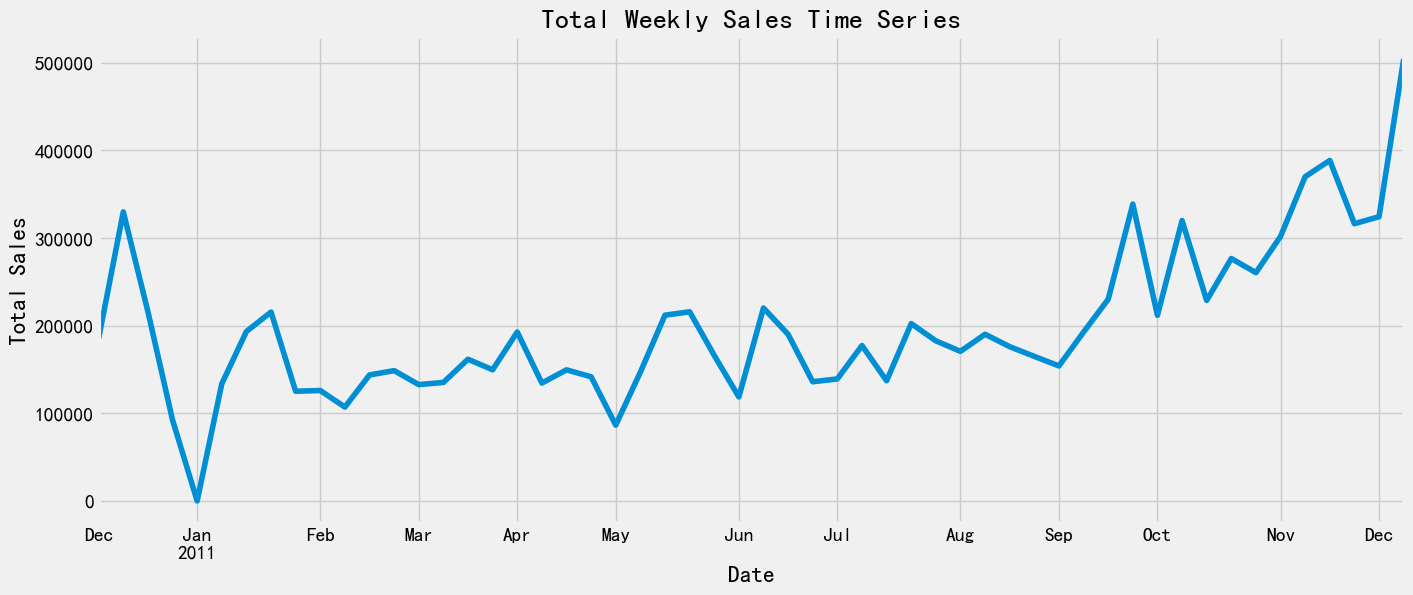


--- Results of Dickey-Fuller Test ---
Test Statistic                  3.582627
p-value                         1.000000
#Lags Used                     10.000000
Number of Observations Used    43.000000
Critical Value (1%)            -3.592504
Critical Value (5%)            -2.931550
Critical Value (10%)           -2.604066
dtype: float64

Result: Fail to Reject Null Hypothesis. Series is NOT stationary. Differencing (d=1) is needed.


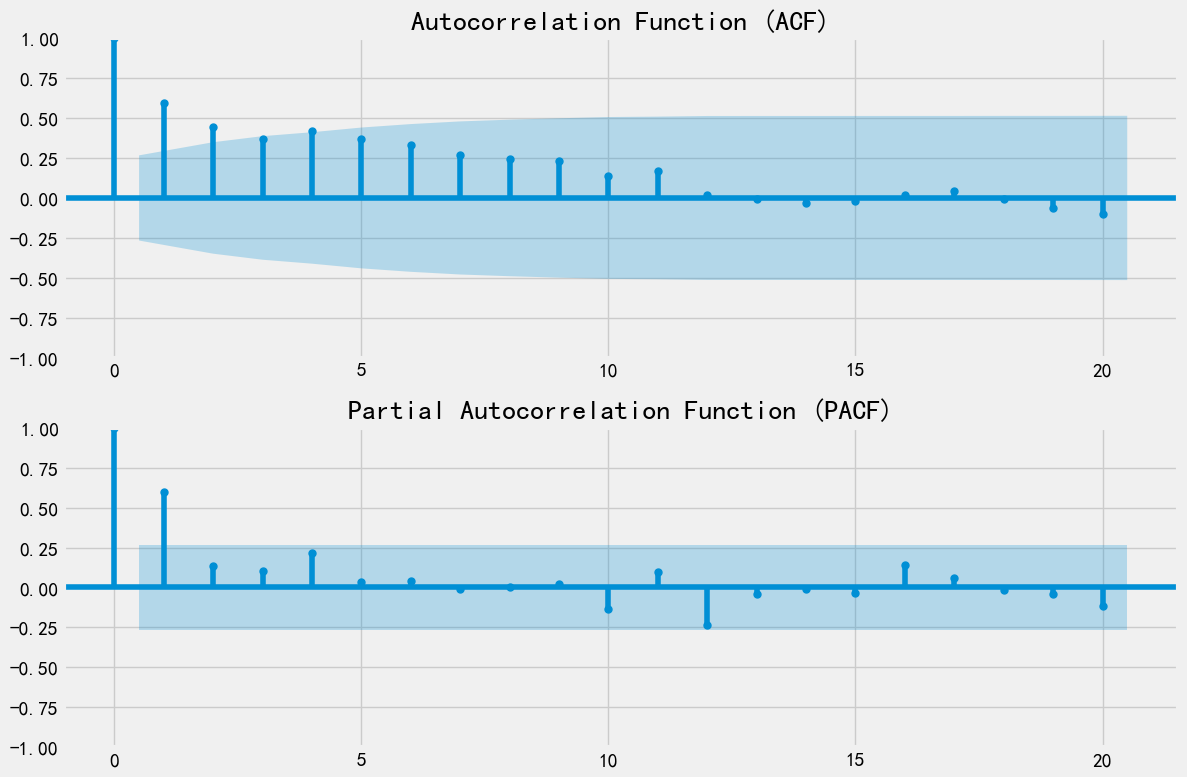


Fitting ARIMA(1, 1, 1) model...
                               SARIMAX Results                                
Dep. Variable:             TotalSales   No. Observations:                   54
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -628.121
Date:                Wed, 12 Nov 2025   AIC                           1262.241
Time:                        12:26:54   BIC                           1268.037
Sample:                    12-05-2010   HQIC                          1264.456
                         - 12-11-2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0335      0.089      0.375      0.707      -0.141       0.208
ma.L1         -1.3642      0.074    -18.437      0.000      -1.509      -1.219
sigma2      2.474e+

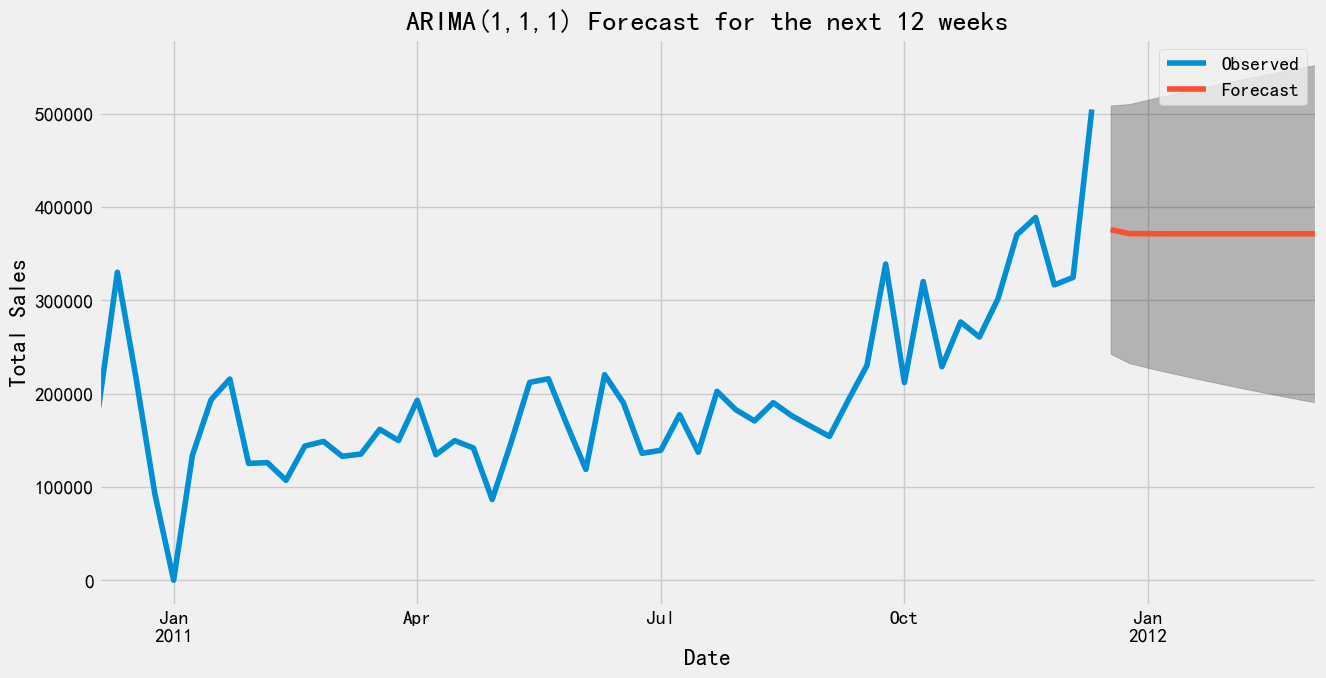


ARIMA model fitting and forecasting complete.


In [41]:
# --- 1. Import Necessary Libraries ---
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Configure plotting style
plt.style.use('fivethirtyeight')

# --- 2. Load and Prepare Data ---

# Define the file path
file_path = 'OnlineRetail.csv'

# Load the dataset, trying 'latin1' encoding if 'utf-8' fails
try:
    df = pd.read_csv(file_path, encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='latin1')

print("Data loaded successfully.")

# Convert InvoiceDate to datetime objects
# The format '%d-%m-%Y %H:%M' matches your data (e.g., '01-12-2010 08:26')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d-%m-%Y %H:%M')

# --- 3. Clean Data and Feature Engineering ---

# Filter out returns/cancellations (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Filter out items with negative quantity or zero unit price
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Calculate TotalSales for each transaction
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

print("Data cleaned and 'TotalSales' column created.")

# --- 4. Create Weekly Time Series ---

# Aggregate sales by day first
ts_daily = df.groupby(pd.Grouper(key='InvoiceDate', freq='D'))['TotalSales'].sum().reset_index()
ts_daily.set_index('InvoiceDate', inplace=True)

# Resample the daily data to Weekly ('W') frequency, summing the sales
y = ts_daily['TotalSales'].resample('W').sum()

# Fill any missing weeks (where no sales occurred) with 0
y = y.fillna(0)

print(f"\nWeekly Time Series (Head):\n{y.head()}")
print(f"\nTotal number of weekly observations: {len(y)}")

# --- 5. Visualization ---

# Plot the weekly time series data
plt.figure(figsize=(15, 6))
y.plot()
plt.title('Total Weekly Sales Time Series')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.savefig('weekly_sales_timeseries.png')
plt.show()

# --- 6. Check for Stationarity (ADF Test) ---

# A stationary series is required for ARIMA
print('\n--- Results of Dickey-Fuller Test ---')
dftest = adfuller(y, autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

if dftest[1] <= 0.05:
    print("\nResult: Reject Null Hypothesis. Series is stationary.")
else:
    print("\nResult: Fail to Reject Null Hypothesis. Series is NOT stationary. Differencing (d=1) is needed.")

# --- 7. Model Order Selection (ACF/PACF) ---

# Plot ACF and PACF to help determine the p, q orders
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(y, lags=20, ax=ax1, title='Autocorrelation Function (ACF)')
plot_pacf(y, lags=20, ax=ax2, title='Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.savefig('acf_pacf_plots.png')
plt.show()

# --- 8. ARIMA Model Fitting and Forecasting ---

# Define the ARIMA model parameters (p,d,q)
p, d, q = 1, 1, 1 # (AR=1, I=1, MA=1)
# d=1 is used because the ADF test showed the data is non-stationary

# We use (0,0,0,0) for the seasonal order as we are fitting a non-seasonal ARIMA
P, D, Q, s = 0, 0, 0, 0

print("\nFitting ARIMA(1, 1, 1) model...")

try:
    # Create and fit the model
    model = SARIMAX(y,
                    order=(p, d, q),
                    seasonal_order=(P, D, Q, s), # No seasonal component
                    enforce_stationarity=False,
                    enforce_invertibility=False)

    results = model.fit(disp=False)
    
    # Print the model summary
    print(results.summary())

    # --- 9. Generate and Plot Forecast ---
    
    forecast_steps = 12 # Forecast for the next 12 weeks
    
    # Get the forecast and confidence intervals
    forecast = results.get_forecast(steps=forecast_steps)
    forecast_ci = forecast.conf_int() # Confidence interval

    # Plot the observed data and the forecast
    plt.figure(figsize=(14, 7))
    ax = y.plot(label='Observed', figsize=(14, 7))
    forecast.predicted_mean.plot(ax=ax, label='Forecast')
    
    # Shade the confidence interval
    ax.fill_between(forecast_ci.index,
                    forecast_ci.iloc[:, 0],
                    forecast_ci.iloc[:, 1], color='k', alpha=.25)

    ax.set_xlabel('Date')
    ax.set_ylabel('Total Sales')
    plt.legend()
    plt.title(f'ARIMA(1,1,1) Forecast for the next {forecast_steps} weeks')
    plt.savefig('sales_forecast.png')
    plt.show()

    print("\nARIMA model fitting and forecasting complete.")

except Exception as e:
    print(f"\nError fitting ARIMA model: {e}")
    print("The data might require different (p,d,q) parameters or further cleaning.")